In [1]:
import pandas as pd

In [1]:
import pandas as pd
import glob
import os

In [3]:
# Define the path to your directory containing Excel files
# You can use a wildcard '*' to match all Excel files (.xlsx or .xls): 
#72622*.csv
excel_files_path = "c:/Users/ukhan/Downloads/2023/*.csv"

In [4]:
# Get a list of all Excel file paths in the specified directory
# glob.glob() returns a list of file paths matching the pattern
excel_files = glob.glob(excel_files_path)

In [5]:
len(excel_files)

12977

In [66]:
df = pd.read_csv('c:/Users/ukhan/Downloads/2024/72622394725.csv')

C:\Users\ukhan\AppData\Local\Temp\ipykernel_47920\3037080109.py:1: DtypeWarning: Columns (2,34,35,41,42,49,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('c:/Users/ukhan/Downloads/2024/72622394725.csv')


In [67]:
df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'AA1', 'AA2', 'AA3', 'AB1', 'AD1', 'AE1',
       'AH1', 'AH2', 'AH3', 'AH4', 'AH5', 'AH6', 'AI1', 'AI2', 'AI3', 'AI4',
       'AI5', 'AI6', 'AL1', 'AN1', 'AT1', 'AT2', 'AT3', 'AT4', 'AT5', 'AT6',
       'AT7', 'AU1', 'AU2', 'AU3', 'AW1', 'AW2', 'AW3', 'AW4', 'AX1', 'AX2',
       'AX3', 'GA1', 'GA2', 'GA3', 'GD1', 'GD2', 'GD3', 'GE1', 'GF1', 'KA1',
       'KA2', 'KB1', 'KB2', 'KB3', 'KC1', 'KC2', 'KD1', 'KD2', 'KE1', 'KG1',
       'KG2', 'MA1', 'MD1', 'MF1', 'MG1', 'MH1', 'MK1', 'MV1', 'MW1', 'OC1',
       'OD1', 'OE1', 'OE2', 'OE3', 'RH1', 'RH2', 'RH3', 'WA1', 'REM', 'EQD'],
      dtype='object')

In [68]:
df['LATITUDE'].value_counts()

44.93341    13278
Name: LATITUDE, dtype: int64

In [54]:
search_string_re = r"ny|new york|NY"

In [ ]:
df['NAME'].str.contains("NO", case=False, na=False) 
.str.contains('an', regex=True, case=False)

In [55]:
df[df['NAME'].str.contains(search_string_re, regex=True, na=False)].head()


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,KA2,MA1,MD1,MW1,OC1,OD1,SA1,UA1,REM,EQD


In [70]:
df[['LATITUDE','LONGITUDE']].value_counts()

LATITUDE  LONGITUDE
44.93341  -74.84836    13278
dtype: int64

In [72]:
df.shape

(13278, 92)

In [75]:
df[(df['LATITUDE']>44) & (df['LONGITUDE']<-74)].shape

(13278, 92)

In [ ]:
((link_metadata_df['site_0_lat']>40.5) & (link_metadata_df['site_0_lat']<40.9)).sum()
((link_metadata_df['site_0_lon']<-73.9) & (link_metadata_df['site_0_lon']>-74.1)).sum()

In [103]:
lat = [44.5, 45]
lon = [-75.1, -73.9]

In [104]:
df[df['LATITUDE'].between(lat[0], lat[1], inclusive='both')].shape

(13278, 92)

In [105]:
df[df['LONGITUDE'].between(lon[0], lon[1], inclusive='both')].shape

(13278, 92)

In [106]:
df[(df['LATITUDE'].between(lat[0], lat[1], inclusive='both') & df['LONGITUDE'].between(lon[0], lon[1], inclusive='both'))].shape

(13278, 92)

In [108]:
df.shape[0]>0

True

In [6]:
#lat = [40.6, 40.8]
#lon = [-74.01, -73.92]
#720*.csv
lat = [39, 42]
lon = [-76, -72]

In [7]:
# Create an empty list to store the individual DataFrames
all_dfs = []

# Loop through each Excel file found
for file_path in excel_files:
    try:
        # Read the Excel file into a Pandas DataFrame
        df = pd.read_csv(file_path)
        
        df = df[(df['LATITUDE'].between(lat[0], lat[1], inclusive='both') & df['LONGITUDE'].between(lon[0], lon[1], inclusive='both'))]
        if df.shape[0]>0:
            # Optional: Add a column to identify the source file
            df['source_file'] = os.path.basename(file_path)
            # Append the DataFrame to the list
            all_dfs.append(df)
            print("lat_lon found in file:"+file_path)
        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Concatenate all individual DataFrames into a single DataFrame
if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print("Combined DataFrame created successfully.")
    print(combined_df.head()) # Display the first few rows of the combined DataFrame
else:
    print("No Excel files found or no DataFrames were successfully read.")


C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (26,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (24,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (24,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (17,18,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_p

lat_lon found in file:c:/Users/ukhan/Downloads/2023\72030464752.csv


C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (22,25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (37,41,46,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_p

lat_lon found in file:c:/Users/ukhan/Downloads/2023\72032464753.csv


C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (20,21,22,23,24,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (23,24,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (16,18,19,20,21,23,24,25,26,27,28,35,39,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or se

...

lat_lon found in file:c:/Users/ukhan/Downloads/2023\74486514719.csv


C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (38,39,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (44,49,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (38,39,40,49,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (40,43,46,47,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (41,47) have mixed types. Specify dtype option on import or set low_memory=False

lat_lon found in file:c:/Users/ukhan/Downloads/2023\74596603726.csv


C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (2,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (34,35,36,42,46,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (36,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\ukhan\AppData\Local\Temp\ipykernel_67288\1556742625.py:8: DtypeWarning: Columns (18,35,36,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.r

lat_lon found in file:c:/Users/ukhan/Downloads/2023\99475099999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99727099999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99727199999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99728099999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99728399999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99728499999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99728699999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99728999999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99729099999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99730099999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99737299999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99768799999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99769499999.csv
lat_lon found in file:c:/Users/ukhan/Downloads/2023\99769899999.csv
Combined DataFrame created successfully.
       

In [8]:
combined_df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL',
       ...
       'AW5', 'ED1', 'GA4', 'GD4', 'MW2', 'MW3', 'MW4', 'AX4', 'AT7', 'SA1'],
      dtype='object', length=108)

In [9]:
combined_df.shape

(830164, 108)

In [10]:
combined_df['NAME'].value_counts()

QUAKERTOWN AIRPORT, PA US                        26308
CHESTER AIRPORT, CT US                           26196
WINGS FIELD, PA US                               25416
EAST HAMPTON AIRPORT, NY US                      24993
CHESTER CO GO CARLSON AIRPORT, PA US             24160
                                                 ...  
NEW LONDON LEDGE LEDGE LIGHT WEATHER S, CT US     6076
LAKEHURST NAS, NJ US                              6073
MONTICELLO SULLIVAN, NY US                        5512
NEW LONDON, CT US                                 5225
OCEAN CO AIRPORT, NJ US                           1261
Name: NAME, Length: 68, dtype: int64

In [11]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830164 entries, 0 to 830163
Columns: 108 entries, STATION to SA1
dtypes: float64(3), int64(1), object(104)
memory usage: 684.0+ MB


In [2]:
target_path="C:/Users/ukhan/Documents/DataSet/OpenMesh/nceia_noaa/"

In [13]:
#lat = [39, 42]
#lon = [-76, -72]
combined_df.to_csv(target_path+"2023_lat_39__42__lon_-76__-72_1.1M.csv", index=False)

In [6]:
#lat = [39, 42]
#lon = [-76, -72]
!set low_memory=False
combined_df = pd.read_csv(target_path+"2023_lat_39__42__lon_-76__-72_1.1M.csv")

C:\Users\ukhan\AppData\Local\Temp\ipykernel_44908\1778237734.py:4: DtypeWarning: Columns (2,8,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,45,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_df = pd.read_csv(target_path+"2023_lat_39__42__lon_-76__-72_1.1M.csv")


In [7]:
combined_df.shape

(830164, 108)

## 2023 data for lat-lon as present under mesh data

In [8]:
lat = [40.6, 40.8]
lon = [-74.01, -73.92]

In [9]:
df=combined_df[(combined_df['LATITUDE'].between(lat[0], lat[1], inclusive='both') & combined_df['LONGITUDE'].between(lon[0], lon[1], inclusive='both'))]

In [10]:
df.shape

(22117, 108)

In [31]:
df.to_csv(target_path+"2023_lat_40_6__40_8__lon_-74_01__-73_92_nyc_21K.csv", index=False)

In [11]:
df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL',
       ...
       'AW5', 'ED1', 'GA4', 'GD4', 'MW2', 'MW3', 'MW4', 'AX4', 'AT7', 'SA1'],
      dtype='object', length=108)

In [16]:
columns_all_na = df.columns[df.isnull().all()].tolist()

In [17]:
len(columns_all_na)

16

In [18]:
df = df.drop(columns=columns_all_na)

In [19]:
df.shape

(22117, 92)

In [21]:
df.isna().sum()

STATION          0
DATE             0
SOURCE           0
LATITUDE         0
LONGITUDE        0
             ...  
MF1          21786
RH1          21784
RH2          21784
RH3          21784
AX4          22115
Length: 92, dtype: int64

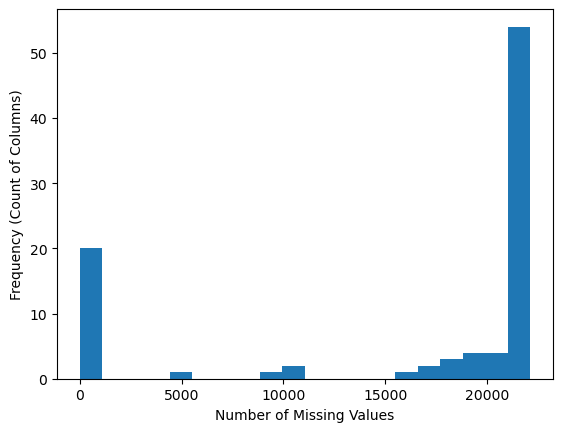

In [23]:
import matplotlib.pyplot as plt

null_counts = df.isna().sum()

#Plot as a histogram using bins
null_counts.plot.hist(bins=20)
plt.xlabel('Number of Missing Values')
plt.ylabel('Frequency (Count of Columns)')
plt.show()

In [24]:
df.columns[df.isna().sum()>20000].to_list()

['AA2',
 'AA3',
 'AT1',
 'AT2',
 'AT3',
 'AT4',
 'AT5',
 'AU2',
 'AW2',
 'AW3',
 'GA3',
 'OD1',
 'AB1',
 'AD1',
 'AE1',
 'AH1',
 'AH2',
 'AH3',
 'AH4',
 'AH5',
 'AH6',
 'AI1',
 'AI2',
 'AI3',
 'AI4',
 'AI5',
 'AI6',
 'AX1',
 'AX2',
 'AX3',
 'KB1',
 'KB2',
 'KB3',
 'KC1',
 'KC2',
 'KD1',
 'KD2',
 'KE1',
 'MG1',
 'MH1',
 'MK1',
 'OE1',
 'OE2',
 'OE3',
 'WA1',
 'AJ1',
 'AK1',
 'AL1',
 'AM1',
 'AN1',
 'KG1',
 'KG2',
 'MF1',
 'RH1',
 'RH2',
 'RH3',
 'AX4']

In [25]:
columns_na_gt_20000 = df.columns[df.isna().sum()>20000].to_list()

In [26]:
len(columns_na_gt_20000)

57

In [27]:
df = df.drop(columns=columns_na_gt_20000)

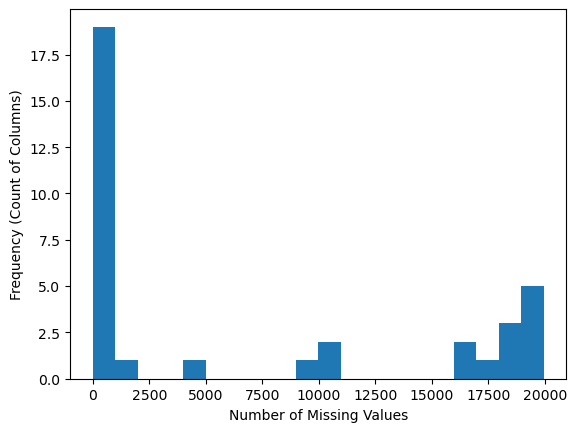

In [28]:
import matplotlib.pyplot as plt

null_counts = df.isna().sum()

#Plot as a histogram using bins
null_counts.plot.hist(bins=20)
plt.xlabel('Number of Missing Values')
plt.ylabel('Frequency (Count of Columns)')
plt.show()

In [36]:
df.isna().sum()

STATION                0
DATE                   0
SOURCE                 0
LATITUDE               0
LONGITUDE              0
ELEVATION              0
NAME                   0
REPORT_TYPE            0
CALL_SIGN              0
QUALITY_CONTROL        0
WND                    0
CIG                    0
VIS                    0
TMP                    0
DEW                    0
SLP                    0
AA1                10488
AU1                18731
AW1                16851
GA1                10702
GA2                19349
GD1                 4706
GD2                17059
GD3                19953
GE1                 9748
GF1                 1000
KA1                18426
KA2                18464
MA1                  388
MW1                19698
OC1                19290
REM                    1
EQD                19201
source_file            0
MD1                16471
dtype: int64

In [37]:
columns_na_gt_10000 = df.columns[df.isna().sum()>10000].to_list()

In [38]:
df = df.drop(columns=columns_na_gt_10000)

In [41]:
df.shape

(22117, 22)

In [42]:
df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'GD1', 'GE1', 'GF1', 'MA1', 'REM',
       'source_file'],
      dtype='object')

2023: ['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'GD1', 'GE1', 'GF1', 'MA1', 'REM',
       'source_file']

2024: ['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'GD1', 'GE1', 'GF1', 'MA1', 'REM',
       'source_file']

In [37]:
columns_na_gt_100 = df.columns[df.isna().sum()>100].to_list()

In [38]:
df = df.drop(columns=columns_na_gt_100)

In [40]:
df.head()


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,VIS,TMP,DEW,SLP,GD1,GE1,GF1,MA1,REM,source_file
103341,72055399999,2023-01-01T00:05:00,4,40.701214,-74.009028,2.13,"PORT AUTH DOWNTN MANHATTAN WALL ST HEL, NY US",FM-16,99999,V020,...,"000805,1,9,9","+9999,9","+9999,9","99999,9","4,99,1,+00091,1,9","9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00091,1,99,9,99,9","10108,1,99999,9",MET071SPECI KJRB 010005Z AUTO 00000KT 1/2SM FG...,72055399999.csv
103342,72055399999,2023-01-01T00:17:00,4,40.701214,-74.009028,2.13,"PORT AUTH DOWNTN MANHATTAN WALL ST HEL, NY US",FM-16,99999,V020,...,"001609,1,9,9","+9999,9","+9999,9","99999,9","4,99,1,+00091,1,9","9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00091,1,99,9,99,9","10108,1,99999,9",MET082SPECI KJRB 010017Z AUTO 25006KT 1SM -RA ...,72055399999.csv
103343,72055399999,2023-01-01T00:20:00,4,40.701214,-74.009028,2.13,"PORT AUTH DOWNTN MANHATTAN WALL ST HEL, NY US",FM-16,99999,V020,...,"004023,1,9,9","+9999,9","+9999,9","99999,9","4,99,1,+00091,1,9","9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00091,1,99,9,99,9","10108,1,99999,9",MET086SPECI KJRB 010020Z AUTO 25005KT 2 1/2SM ...,72055399999.csv
103344,72055399999,2023-01-01T00:27:00,4,40.701214,-74.009028,2.13,"PORT AUTH DOWNTN MANHATTAN WALL ST HEL, NY US",FM-16,99999,V020,...,"001609,1,9,9","+9999,9","+9999,9","99999,9","4,99,1,+00091,1,9","9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00091,1,99,9,99,9","10108,1,99999,9",MET099SPECI KJRB 010027Z AUTO 24005KT 1SM UP O...,72055399999.csv
103345,72055399999,2023-01-01T00:32:00,4,40.701214,-74.009028,2.13,"PORT AUTH DOWNTN MANHATTAN WALL ST HEL, NY US",FM-16,99999,V020,...,"000805,1,9,9","+9999,9","+9999,9","99999,9","4,99,1,+00091,1,9","9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00091,1,99,9,99,9","10108,1,99999,9",MET091SPECI KJRB 010032Z AUTO 22004KT 1/2SM UP...,72055399999.csv


In [40]:
df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'REM', 'source_file'],
      dtype='object')

In [43]:
df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'GD1', 'GE1', 'GF1', 'MA1', 'REM',
       'source_file'],
      dtype='object')

In [41]:
len(df.columns)

18

In [42]:
df.shape

(22117, 18)

In [43]:
df.to_csv(target_path+"2023_lat_40_6__40_8__lon_-74_01__-73_92_nyc_22K_1.csv", index=False)

In [44]:
df.to_csv(target_path+"2023_lat_40_6__40_8__lon_-74_01__-73_92_nyc_22K_1_22cols.csv", index=False)